<a href="https://colab.research.google.com/github/Renad110/IT326/blob/main/Clustring.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [115]:
import pandas as pd
url = "https://raw.githubusercontent.com/Renad110/IT326/refs/heads/main/Dataset/Raw_dataset/bank-additional-full.csv"
df = pd.read_csv(url, sep=";")
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [116]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Extract features (drop y)
features = df.drop('y', axis=1)

# Separate categorical and numerical features
categorical_features = features.select_dtypes(include=['object']).columns
numerical_features = features.select_dtypes(exclude=['object']).columns

# One-hot encode categorical features
df_categorical_encoded = pd.get_dummies(features[categorical_features], drop_first=True)

# Combine numerical and encoded categorical features
features_processed = pd.concat([features[numerical_features], df_categorical_encoded], axis=1)

# Standardize the processed features
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features_processed)

# create new DF
df_scaled = pd.DataFrame(scaled_features, columns=features_processed.columns)
print("\nScaled DataFrame:")
print(df_scaled.head())


Scaled DataFrame:
        age  duration  campaign     pdays  previous  emp.var.rate  \
0  1.533034  0.010471 -0.565922  0.195414 -0.349494      0.648092   
1  1.628993 -0.421501 -0.565922  0.195414 -0.349494      0.648092   
2 -0.290186 -0.124520 -0.565922  0.195414 -0.349494      0.648092   
3 -0.002309 -0.413787 -0.565922  0.195414 -0.349494      0.648092   
4  1.533034  0.187888 -0.565922  0.195414 -0.349494      0.648092   

   cons.price.idx  cons.conf.idx  euribor3m  nr.employed  ...  month_may  \
0        0.722722       0.886447    0.71246      0.33168  ...   1.411155   
1        0.722722       0.886447    0.71246      0.33168  ...   1.411155   
2        0.722722       0.886447    0.71246      0.33168  ...   1.411155   
3        0.722722       0.886447    0.71246      0.33168  ...   1.411155   
4        0.722722       0.886447    0.71246      0.33168  ...   1.411155   

   month_nov  month_oct  month_sep  day_of_week_mon  day_of_week_thu  \
0  -0.332532  -0.133197  -0.118462   

/tmp/ipython-input-3688658660.py:22: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


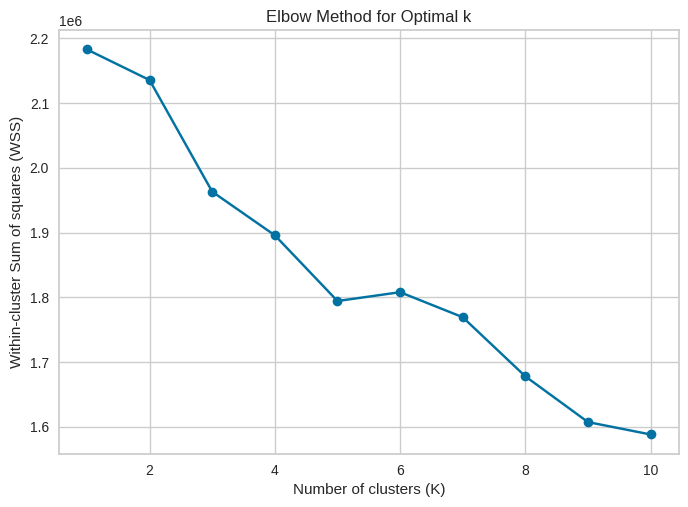

In [117]:
!pip install kneed
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from kneed import KneeLocator

# Use Elbow Method to suggest good K values
wcss_values = []        # list to store within-cluster sum of squares
K_values = range(1, 11) # try K from 2 to 10

for k in K_values:
    kmeans = make_pipeline(StandardScaler(), KMeans(n_clusters=k))
    kmeans.fit(df_scaled)
    wcss_values.append(kmeans.named_steps['kmeans'].inertia_)

# Plot the elbow method
plt.plot(K_values, wcss_values, marker='o')
plt.xlabel("Number of clusters (K)")
plt.ylabel("Within-cluster Sum of squares (WSS)")
plt.title("Elbow Method for Optimal k")
plt.legend()
plt.show()

In [118]:
# Run k-means with k=2 (candicate from Elbow)
import numpy as np
from sklearn.cluster import KMeans
np.random.seed(42)

kmeans = KMeans(n_clusters=2, random_state=42)
kmeans_result = kmeans.fit(df_scaled)

print("Cluster Centers:")
print(kmeans.cluster_centers_)

print("\nCluster Labels:")
print(kmeans_result.labels_)

Cluster Centers:
[[ 1.40225055e-02 -1.87054992e-02  9.29496644e-02  1.95413900e-01
  -3.48594827e-01  6.79190686e-01  4.91610047e-01  2.39951844e-01
   7.00589593e-01  6.48198746e-01  2.70325231e-02  1.20590916e-02
   2.62887594e-02  3.02999705e-05 -6.31892986e-02  3.64622169e-03
   7.95044597e-03 -9.87063328e-02  3.34473170e-02 -8.53975639e-03
   1.29035248e-02  6.34697382e-02 -7.72885438e-02 -7.04412334e-03
   1.32464317e-02  8.75089400e-03 -1.58130396e-02 -1.38649305e-03
   1.30658353e-02 -2.04965403e-02 -5.46960309e-04  1.33918567e-01
   1.58508334e-04  3.15677661e-03 -4.23903687e-02  3.15677661e-03
  -1.07387100e-03  2.94487564e-01  1.17541455e-01 -6.66211293e-02
   1.94592330e-01  9.88201620e-02 -1.15906765e-01 -9.82099180e-02
   2.62455920e-02 -1.14774055e-01 -1.18461754e-01 -1.96497133e-02
  -6.73318058e-03  1.56867236e-02  2.13573549e-02  3.96409637e-01
  -1.85700002e-01]
 [-2.65649124e-02  3.54366020e-02 -1.76088338e-01 -3.70201540e-01
   6.60394895e-01 -1.28669167e+00 -9.313

In [119]:
# Run k-means with k=3 (candicate from Elbow)
import numpy as np
from sklearn.cluster import KMeans
np.random.seed(42)

kmeans = KMeans(n_clusters=3, random_state=42)
kmeans_result = kmeans.fit(df_scaled)

print("Cluster Centers:")
print(kmeans.cluster_centers_)

print("\nCluster Labels:")
print(kmeans_result.labels_)

Cluster Centers:
[[ 7.07983388e-03 -3.38936271e-02  8.16570533e-02  1.95413900e-01
  -2.58531742e-01  6.16686589e-01  2.74342814e-02  3.99356181e-02
   6.59771484e-01  7.41055067e-01 -1.04388514e-01  1.07791811e-02
   3.26165507e-02  2.19667146e-02 -6.04650693e-02  1.44929745e-02
  -3.86438434e-02 -1.08077305e-01  1.20327712e-01 -4.38299327e-03
  -1.61709827e-02  7.78347599e-03 -2.35011661e-02 -1.01316810e-02
  -5.09128040e-02 -6.45413980e-02 -4.23128638e-02  1.02157024e-02
   5.44998112e-02  1.18306972e-01 -3.27571445e-02  1.41610719e-02
   1.43334148e-02 -3.16358624e-02  5.20371244e-02 -3.16358624e-02
   1.72550071e-02 -5.64828851e-01  5.21472756e-01 -6.66211293e-02
   6.76937571e-01 -3.85042331e-01 -1.15906765e-01 -7.08639561e-01
   4.44615188e-01 -1.31706172e-01 -1.18461754e-01 -1.63147795e-02
   4.58520044e-02  2.58202238e-02  2.16133249e-02  2.66610981e-01
  -1.85700002e-01]
 [-3.32091633e-02  4.63255200e-02 -1.71975275e-01 -3.98630510e-01
   6.09742145e-01 -1.34554399e+00 -9.455

In [120]:
# Run k-means with k=4 (candicate from Elbow)
import numpy as np
from sklearn.cluster import KMeans
np.random.seed(42)

kmeans = KMeans(n_clusters=4, random_state=42)
kmeans_result = kmeans.fit(df_scaled)

print("Cluster Centers:")
print(kmeans.cluster_centers_)

print("\nCluster Labels:")
print(kmeans_result.labels_)

Cluster Centers:
[[ 1.79289160e-03 -3.68343112e-02  8.30766090e-02  1.95413900e-01
  -2.58172575e-01  6.16337859e-01  2.07961707e-02  5.04892935e-02
   6.59589349e-01  7.40891792e-01 -1.50514828e-01  1.38722155e-02
   2.66039609e-02  3.07421653e-02 -6.24481567e-02  1.90647328e-02
  -4.16948436e-02 -1.06732721e-01  1.41592405e-01 -3.82123250e-03
  -1.50503069e-02 -6.53946946e-03 -1.14152283e-02 -1.01047293e-02
  -2.42747539e-01 -4.89098130e-02 -1.90646564e-02  1.16562965e-02
   7.46988613e-02  1.53454429e-01 -2.49182281e-02 -2.61272824e-03
   1.53918381e-02 -3.02805882e-02  5.20214499e-02 -3.02805882e-02
   1.90312417e-02 -5.65474179e-01  5.42176641e-01 -6.66211293e-02
   6.56482321e-01 -3.85042331e-01 -1.15906765e-01 -7.08639561e-01
   4.46259414e-01 -1.32677292e-01 -1.18461754e-01 -1.32774027e-02
   4.60273537e-02  2.28286985e-02  1.83888759e-02  2.66093351e-01
  -1.85700002e-01]
 [ 3.21831458e-02  2.03588101e-02  3.39332425e-03  1.85906146e-01
  -1.49602025e-01  1.39555600e-01  1.606

In [121]:
# Run silhouette and WCSS with chosen clusters (candicate from Elbow)
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

k_values = [2, 3, 4]

silhouette_scores = []
wcss = []

print("Silhouette Scores:")
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(df_scaled)
    silhouette = silhouette_score(df_scaled, labels)
    silhouette_scores.append(silhouette)
    print(f"K = {k} , Silhouette = {silhouette}")

print("\nWCSS:")
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(df_scaled)
    wcss.append(kmeans.inertia_)
    print(f"K = {k} , WCSS = {kmeans.inertia_}")

Silhouette Scores:
K = 2 , Silhouette = 0.12236968560213422
K = 3 , Silhouette = 0.05089866620204413
K = 4 , Silhouette = 0.05563729457503009

WCSS:
K = 2 , WCSS = 2004714.4504902721
K = 3 , WCSS = 1931814.8664505456
K = 4 , WCSS = 1897043.5420534902


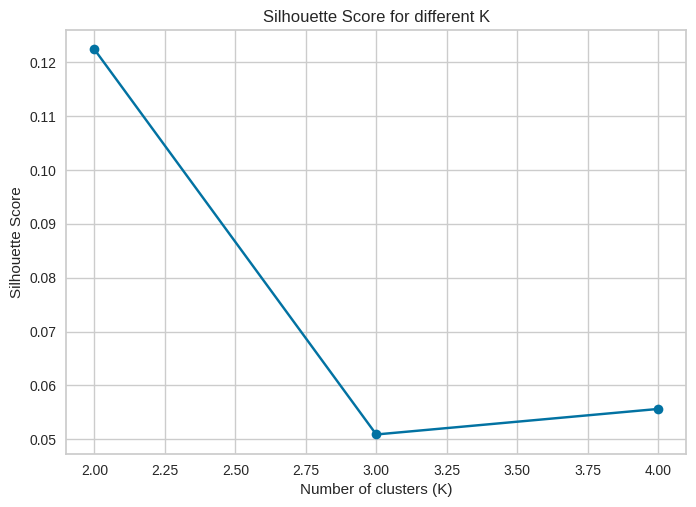

In [122]:
# Plot Silhouette for the 3 Ks
plt.plot(k_values, silhouette_scores, marker='o')
plt.title("Silhouette Score for different K")
plt.xlabel("Number of clusters (K)")
plt.ylabel("Silhouette Score")
plt.show()

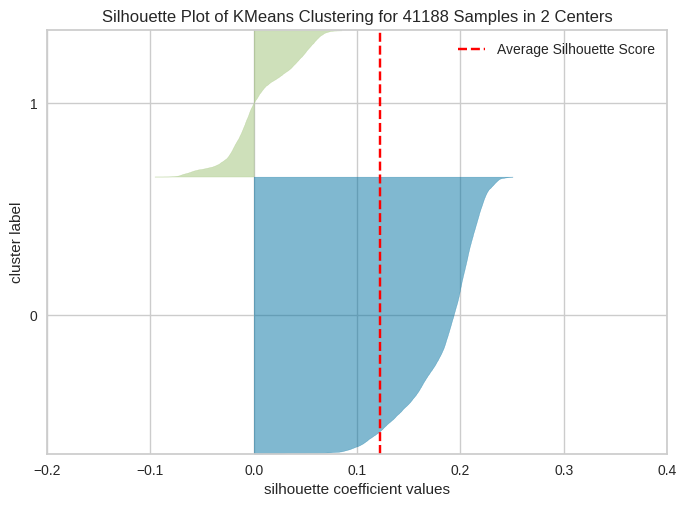

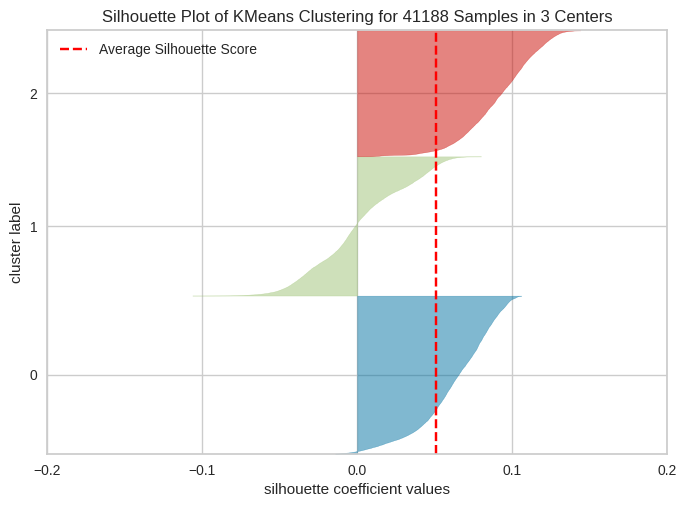

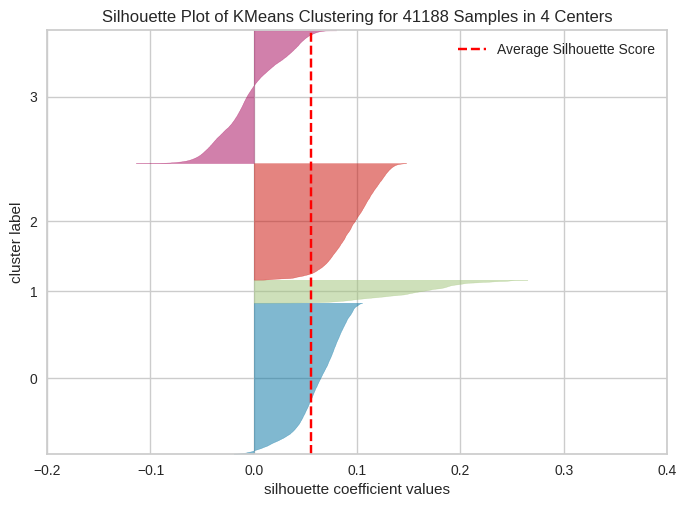

In [123]:
# Visualizing the silhouette plots for each K value to compare clustering quality
from yellowbrick.cluster import SilhouetteVisualizer
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    visualizer = SilhouetteVisualizer(kmeans, colors="yellowbrick")
    visualizer.fit(df_scaled)
    visualizer.show()

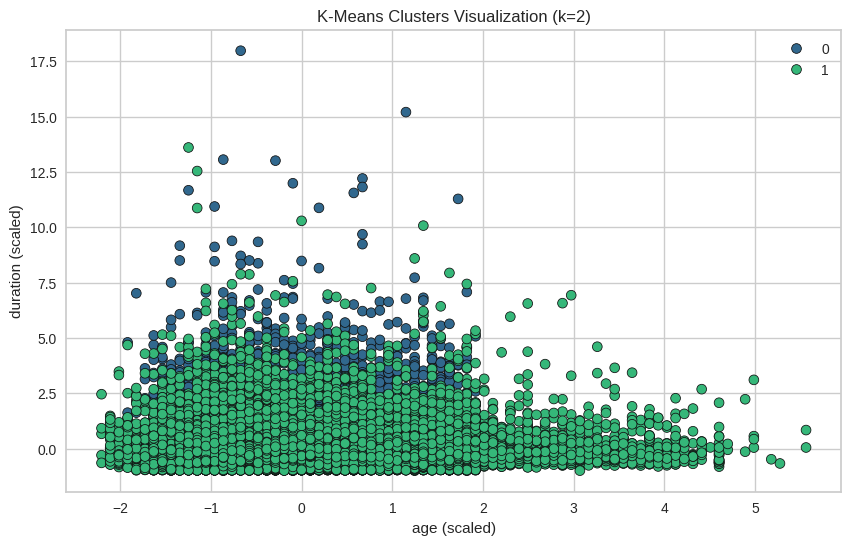

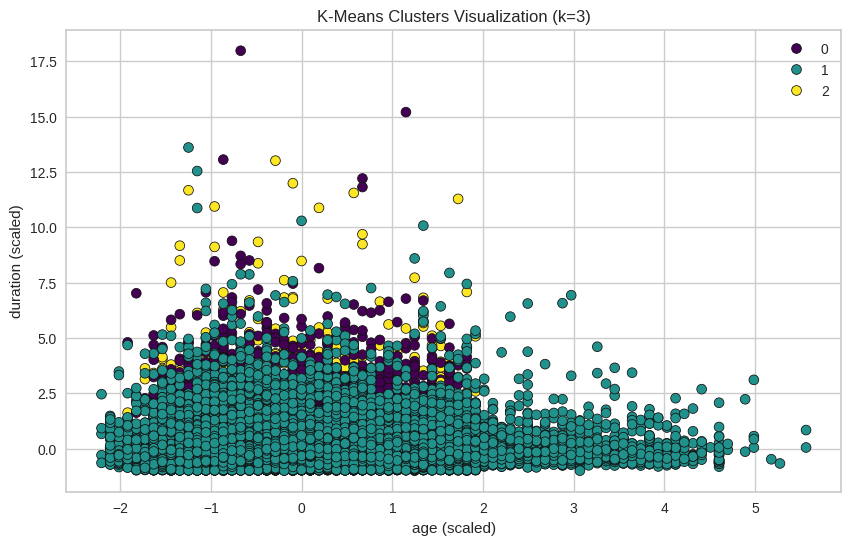

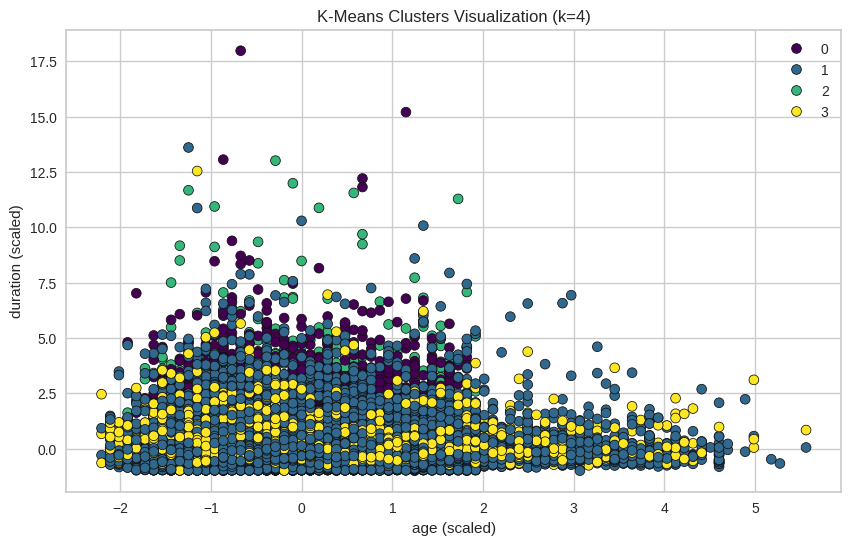

In [124]:
# Clustering visualization (scatter plot)
!pip install seaborn
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import seaborn as sns

k_values = [2, 3, 4]

# visualizing clustering for each chosen K
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans_result = kmeans.fit(df_scaled)

    # Add cluster labels to the original DataFrame
    df_scaled["Cluster"] = kmeans_result.labels_

    # Create scatter plot for two numeric features
    plt.figure(figsize=(10, 6))

    # We use 'age' and 'duration' as example features
    sns.scatterplot(
        x="age",          # first feature on x-axis
        y="duration",     # second feature on y-axis
        hue="Cluster",    # color points by cluster label
        data=df_scaled ,
        palette="viridis",
        edgecolor="k"
)

    plt.title(f"K-Means Clusters Visualization (k={k})")
    plt.xlabel("age (scaled)")
    plt.ylabel("duration (scaled)")
    plt.legend()
    plt.show()
